In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats as scipy_stats
from scipy.ndimage import gaussian_filter
import datetime
import os
import time
from nba_api.stats.endpoints import (
    leaguedashplayerstats, leaguedashplayerclutch, playerawards,
    shotchartdetail, leagueseasonmatchups
)

In [73]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'text.color': '#1A1A2E',
    'axes.labelcolor': '#2D3436',
    'xtick.color': '#636E72',
    'ytick.color': '#636E72',
    'axes.edgecolor': '#DFE6E9',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

tier_colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}
tier_order = ['Role', 'Star', 'Olympic Gold Medalist']

def add_titles(fig, title, subtitle):
    fig.text(0.06, 0.98, title, fontsize=17, fontweight='bold', ha='left')
    fig.text(0.06, 0.925, subtitle, fontsize=11.5, color='#636E72', ha='left')

In [74]:
player_stats_advanced_df = pd.read_parquet('all_seasons_advanced.parquet')
player_stats_basic_df = pd.read_parquet('all_seasons_basic.parquet')
clutch_adv_df = pd.read_parquet('all_seasons_clutch.parquet')
all_awards_df = pd.read_parquet('all_awards_full.parquet')
home_clutch_df = pd.read_parquet('all_seasons_clutch_home.parquet')
road_clutch_df = pd.read_parquet('all_seasons_clutch_road.parquet')

print(f"{len(player_stats_advanced_df)} advanced, {len(player_stats_basic_df)} basic, "
      f"{len(clutch_adv_df)} clutch, {len(all_awards_df)} award rows loaded")

11059 advanced, 11059 basic, 9686 clutch, 4500 award rows loaded


In [75]:
star_descriptions = ['All-NBA', 'NBA Most Valuable Player', 'NBA Finals Most Valuable Player',
                      'NBA All-Star Most Valuable Player', 'NBA All-Star']
star_mask = all_awards_df['DESCRIPTION'].isin(star_descriptions)
star_player_ids = all_awards_df.loc[star_mask, 'PERSON_ID'].unique()

gold_mask = all_awards_df['DESCRIPTION'] == 'Olympic Gold Medal'
gold_medalist_ids = all_awards_df.loc[gold_mask, 'PERSON_ID'].unique()
olympic_gold_ids = np.intersect1d(star_player_ids, gold_medalist_ids)

print(f"{len(star_player_ids)} career stars, {len(olympic_gold_ids)} Olympic Gold Medalists")

183 career stars, 53 Olympic Gold Medalists


In [76]:
adv_cols = ['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'MIN',
            'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'EFG_PCT', 'TS_PCT',
            'USG_PCT', 'PIE', 'POSS', 'SEASON']
base_cols = ['PLAYER_ID', 'FGA', 'FG3A', 'FTA', 'PTS', 'PLUS_MINUS', 'REB', 'AST', 'SEASON']

season_df = player_stats_advanced_df[adv_cols].merge(
    player_stats_basic_df[base_cols], on=['PLAYER_ID', 'SEASON'], how='inner'
)
season_df = season_df[season_df['FGA'] > 100].copy()

season_df['group'] = np.where(
    season_df['PLAYER_ID'].isin(olympic_gold_ids), 'Olympic Gold Medalist',
    np.where(season_df['PLAYER_ID'].isin(star_player_ids), 'Star', 'Role')
)
print(season_df['group'].value_counts())

group
Role                     6484
Star                     1166
Olympic Gold Medalist     612
Name: count, dtype: int64


In [77]:
clutch_cols = ['PLAYER_ID', 'SEASON', 'GP', 'MIN', 'EFG_PCT', 'TS_PCT', 'USG_PCT',
               'NET_RATING', 'PIE', 'FGA']
clutch_slim = clutch_adv_df[clutch_cols]

df = season_df.merge(clutch_slim, on=['PLAYER_ID', 'SEASON'], how='inner', suffixes=('_SEASON', '_CLUTCH'))
df = df[df['GP_CLUTCH'] >= 15].copy()
df['TS_DELTA'] = df['TS_PCT_CLUTCH'] - df['TS_PCT_SEASON']
df['USG_DELTA'] = df['USG_PCT_CLUTCH'] - df['USG_PCT_SEASON']
df['ts_quintile'] = pd.qcut(df['TS_PCT_SEASON'], q=5,
                              labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%'])

print(f"{len(df)} player-seasons with 15+ clutch games")

5086 player-seasons with 15+ clutch games


## Chart 1

Season vs. clutch True Shooting % for six current players (JJJ, Paolo, Giannis, Embiid, Jrue Holiday, Jalen Duren), filtered to 20+ clutch shot attempts so the drops aren't small-sample noise. A hook, not evidence — single-season numbers are volatile, and the rest of the demo tests whether this holds up over 22 years.

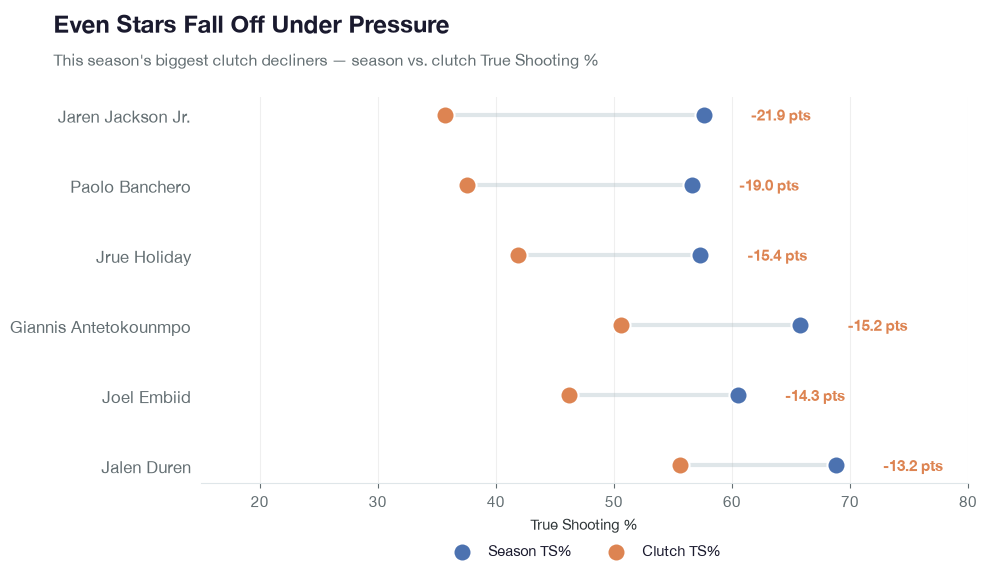

In [78]:
current_season = df[
    (df['SEASON'] == '2025-26') &
    (df['group'].isin(['Star', 'Olympic Gold Medalist'])) &
    (df['FGA_CLUTCH'] >= 20)
].copy()

hook_players = current_season.nsmallest(6, 'TS_DELTA')[
    ['PLAYER_NAME', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH', 'TS_DELTA', 'FGA_CLUTCH']
]

hook_sorted = hook_players.sort_values('TS_DELTA').reset_index(drop=True)
y_pos = range(len(hook_sorted))

fig, ax = plt.subplots(figsize=(10, 6))
for y, row in zip(y_pos, hook_sorted.itertuples()):
    ax.plot([row.TS_PCT_SEASON * 100, row.TS_PCT_CLUTCH * 100], [y, y],
            color='#DFE6E9', linewidth=3, zorder=1, solid_capstyle='round')

ax.scatter(hook_sorted['TS_PCT_SEASON'] * 100, y_pos, s=170, color='#4C72B0',
           zorder=3, label='Season TS%', edgecolor='white', linewidth=1.5)
ax.scatter(hook_sorted['TS_PCT_CLUTCH'] * 100, y_pos, s=170, color='#DD8452',
           zorder=3, label='Clutch TS%', edgecolor='white', linewidth=1.5)

for y, row in zip(y_pos, hook_sorted.itertuples()):
    x_right = max(row.TS_PCT_SEASON, row.TS_PCT_CLUTCH) * 100 + 4
    ax.text(x_right, y, f'{row.TS_DELTA * 100:+.1f} pts', va='center',
            fontsize=11, fontweight='bold', color='#DD8452')

ax.set_yticks(y_pos)
ax.set_yticklabels([row.PLAYER_NAME for row in hook_sorted.itertuples()], fontsize=12)
ax.invert_yaxis()
ax.set_xlim(15, 80)
ax.set_xlabel('True Shooting %', fontsize=10.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
ax.tick_params(left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=10.5)

add_titles(fig, 'Even Stars Fall Off Under Pressure',
           "This season's biggest clutch decliners — season vs. clutch True Shooting %")
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.show()

In [100]:
hook_context = current_season.nsmallest(6, 'TS_DELTA')[
    ['PLAYER_ID', 'PLAYER_NAME', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH', 'TS_DELTA', 'FGA_CLUTCH']
].sort_values('TS_DELTA').reset_index(drop=True)

# Check 1: is 2025-26 an unusually hot season for them, career-wise?
career_ts = (player_stats_advanced_df[player_stats_advanced_df['PLAYER_ID'].isin(hook_context['PLAYER_ID'])]
             .groupby('PLAYER_ID')['TS_PCT'].mean().rename('CAREER_TS_PCT'))
hook_context = hook_context.merge(career_ts, on='PLAYER_ID')
hook_context['SEASON_VS_CAREER'] = (hook_context['TS_PCT_SEASON'] - hook_context['CAREER_TS_PCT']) * 100

# Check 2: is the clutch drop bigger than sample-size noise alone would predict?
hook_context['SE'] = np.sqrt(hook_context['TS_PCT_SEASON'] * (1 - hook_context['TS_PCT_SEASON']) / hook_context['FGA_CLUTCH'])
hook_context['Z_SCORE'] = hook_context['TS_DELTA'] / hook_context['SE']
hook_context['P_VALUE'] = 2 * (1 - scipy_stats.norm.cdf(np.abs(hook_context['Z_SCORE'])))

hook_context[['PLAYER_NAME', 'TS_PCT_SEASON', 'CAREER_TS_PCT', 'SEASON_VS_CAREER',
              'TS_DELTA', 'FGA_CLUTCH', 'Z_SCORE', 'P_VALUE']]

,PLAYER_NAME,TS_PCT_SEASON,CAREER_TS_PCT,SEASON_VS_CAREER,TS_DELTA,FGA_CLUTCH,Z_SCORE,P_VALUE
0,Jaren Jackson Jr.,0.576,0.575375,0.062500,-0.219,37,-2.695571,0.007027
1,Paolo Banchero,0.566,0.548000,1.800000,-0.190,80,-3.428827,0.000606
2,Jrue Holiday,0.573,0.547000,2.600000,-0.154,29,-1.676596,0.093621
3,Giannis Antetokounmpo,0.658,0.607154,5.084615,-0.152,39,-2.001013,0.045391
4,Joel Embiid,0.605,0.607600,-0.260000,-0.143,40,-1.850077,0.064302
5,Jalen Duren,0.688,0.674750,1.325000,-0.132,29,-1.534269,0.124964


## Chart 2

Each icon = 1% of all player-seasons with 100+ FGA across 22 seasons: 79% Role, 14% Star, 7% Olympic Gold Medalist. Sets the scale of "reputation" before any clutch numbers appear.

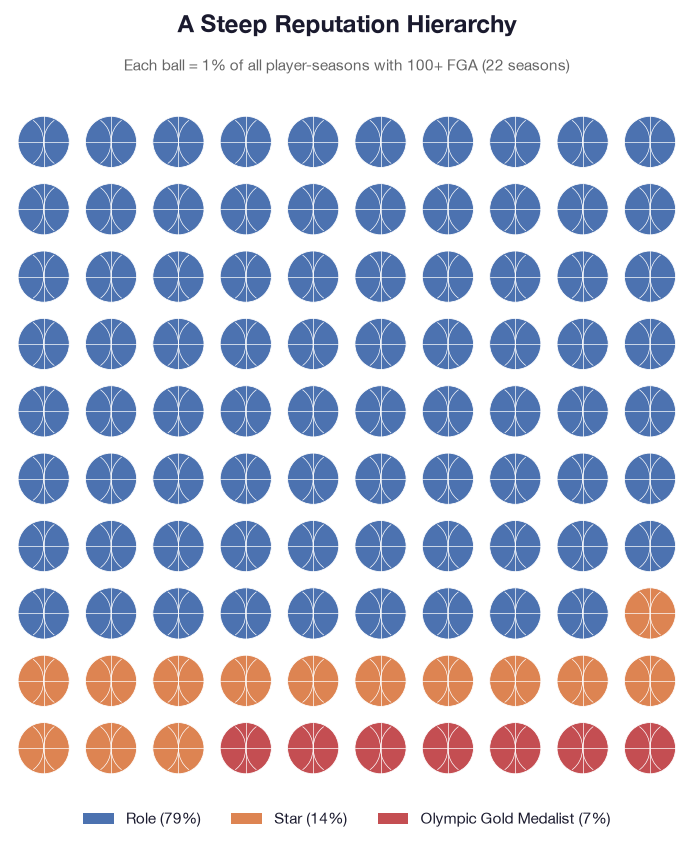

In [79]:
def draw_mini_basketball(ax, cx, cy, r, color):
    ax.add_patch(patches.Circle((cx, cy), radius=r, facecolor=color, edgecolor='white', linewidth=0.6, zorder=2))
    ax.plot([cx, cx], [cy - r, cy + r], color='white', linewidth=0.5, zorder=3)
    ax.plot([cx - r, cx + r], [cy, cy], color='white', linewidth=0.5, zorder=3)
    ax.add_patch(patches.Arc((cx - r*0.9, cy), r*1.8, r*2, theta1=300, theta2=60, color='white', linewidth=0.5, zorder=3))
    ax.add_patch(patches.Arc((cx + r*0.9, cy), r*1.8, r*2, theta1=120, theta2=240, color='white', linewidth=0.5, zorder=3))

counts = season_df['group'].value_counts()
props = (counts / counts.sum() * 100).round().astype(int)
props_ordered = {t: props[t] for t in tier_order}
props_ordered[tier_order[0]] += 100 - sum(props_ordered.values())  # absorb rounding

grid = []
for tier in tier_order:
    grid += [tier] * props_ordered[tier]

fig, ax = plt.subplots(figsize=(8, 8.5))
rows, cols = 10, 10
r = 0.38
for i, tier in enumerate(grid):
    row, col = i // cols, i % cols
    draw_mini_basketball(ax, col + 0.5, rows - 1 - row + 0.5, r, tier_colors[tier])

ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.set_aspect('equal')
ax.axis('off')

legend_handles = [patches.Patch(facecolor=tier_colors[t], label=f'{t} ({props_ordered[t]}%)') for t in tier_order]
ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=11)

fig.text(0.5, 0.97, 'A Steep Reputation Hierarchy', fontsize=17, fontweight='bold', ha='center')
fig.text(0.5, 0.925, 'Each ball = 1% of all player-seasons with 100+ FGA (22 seasons)',
          fontsize=11, color='#666666', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## Chart 3

Five season-long metrics by tier — TS%, EFG%, Usage%, Net Rating, PIE. Stars lead on all five, not just shooting, which rules out "stars aren't actually better" as an explanation for anything that follows.

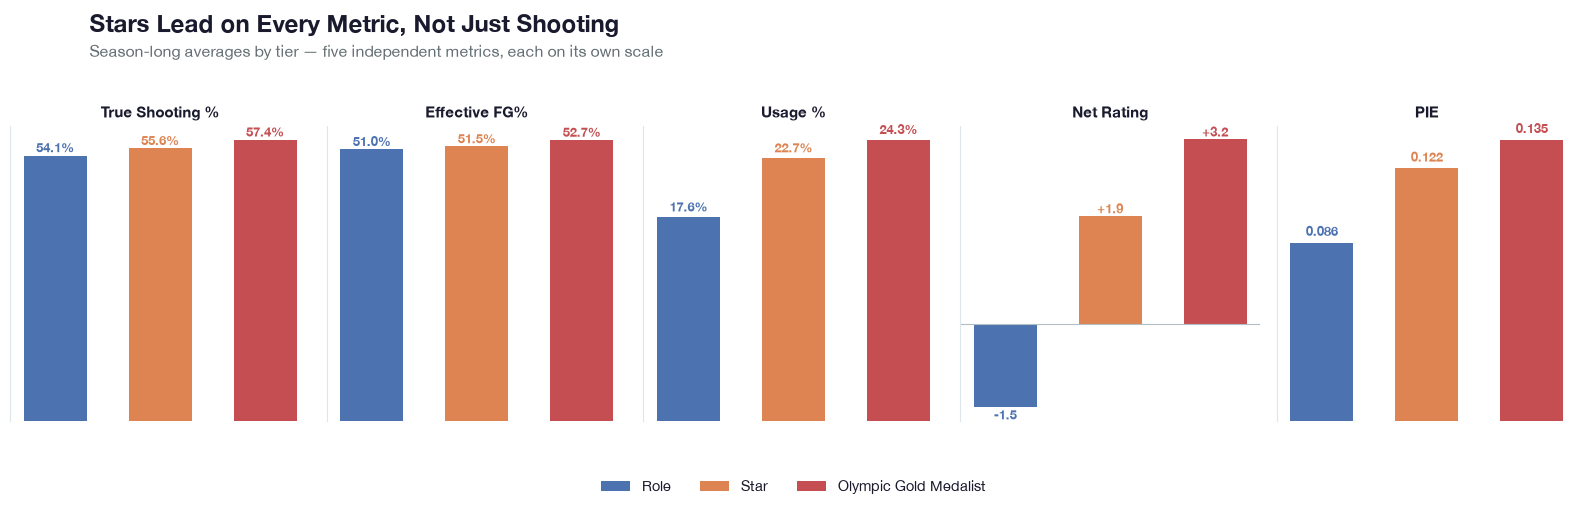

In [96]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))

metric_specs = [
    ('TS_PCT', 'True Shooting %', lambda v: f'{v*100:.1f}%'),
    ('EFG_PCT', 'Effective FG%', lambda v: f'{v*100:.1f}%'),
    ('USG_PCT', 'Usage %', lambda v: f'{v*100:.1f}%'),
    ('NET_RATING', 'Net Rating', lambda v: f'{v:+.1f}'),
    ('PIE', 'PIE', lambda v: f'{v:.3f}'),
]

for ax, (metric, label, fmt) in zip(axes, metric_specs):
    vals = tier_means[metric].reindex(tier_order)
    bars = ax.bar(range(3), vals, color=[tier_colors[t] for t in tier_order], width=0.6)

    for bar, tier in zip(bars, tier_order):
        v = tier_means.loc[tier, metric]
        y_offset = (vals.max() - vals.min()) * 0.04 if vals.min() >= 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, v + y_offset if v >= 0 else v - y_offset,
                fmt(v), ha='center', va='bottom' if v >= 0 else 'top', fontsize=9,
                fontweight='bold', color=tier_colors[tier])

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if metric == 'NET_RATING':
        ax.axhline(0, color='#B2BEC3', linewidth=0.8)
    ax.set_yticks([])

legend_handles = [patches.Patch(facecolor=tier_colors[t], label=t) for t in tier_order]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False, fontsize=10.5)

add_titles(fig, 'Stars Lead on Every Metric, Not Just Shooting',
           'Season-long averages by tier — five independent metrics, each on its own scale')

plt.tight_layout(rect=[0, 0.08, 1, 0.86])
plt.show()

## Chart 4

*Sub-question: does clutch efficiency match season efficiency?* All tiers decline (Role −0.6, Star −1.3, Olympic Gold Medalist −1.1 pts). Not a clean ladder — Olympic Gold Medalist declines less than Star, worth saying plainly.

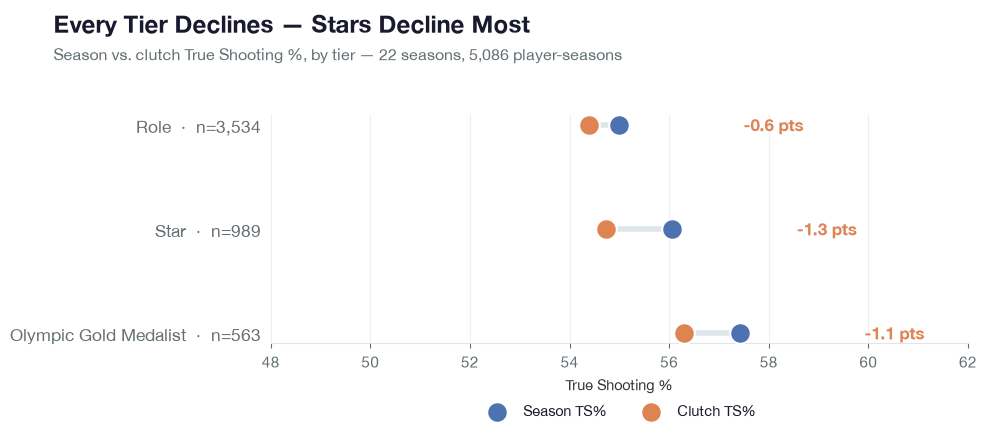

In [81]:
tier_ts = df.groupby('group')[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean().reindex(tier_order)
tier_ts['TS_DELTA'] = tier_ts['TS_PCT_CLUTCH'] - tier_ts['TS_PCT_SEASON']
tier_counts = df['group'].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(tier_order))

for y, tier in zip(y_pos, tier_order):
    row = tier_ts.loc[tier]
    ax.plot([row['TS_PCT_SEASON'] * 100, row['TS_PCT_CLUTCH'] * 100], [y, y],
            color='#DFE6E9', linewidth=4, zorder=1, solid_capstyle='round')

ax.scatter(tier_ts['TS_PCT_SEASON'] * 100, y_pos, s=220, color='#4C72B0',
           zorder=3, label='Season TS%', edgecolor='white', linewidth=1.5)
ax.scatter(tier_ts['TS_PCT_CLUTCH'] * 100, y_pos, s=220, color='#DD8452',
           zorder=3, label='Clutch TS%', edgecolor='white', linewidth=1.5)

for y, tier in zip(y_pos, tier_order):
    row = tier_ts.loc[tier]
    x_right = max(row['TS_PCT_SEASON'], row['TS_PCT_CLUTCH']) * 100 + 2.5
    ax.text(x_right, y, f"{row['TS_DELTA'] * 100:+.1f} pts", va='center',
            fontsize=12.5, fontweight='bold', color='#DD8452')

labels = [f"{t}  ·  n={tier_counts[t]:,}" for t in tier_order]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12.5)
ax.invert_yaxis()
ax.set_xlim(48, 62)
ax.set_xlabel('True Shooting %', fontsize=10.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
ax.tick_params(left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=10.5)

add_titles(fig, 'Every Tier Declines — Stars Decline Most',
           'Season vs. clutch True Shooting %, by tier — 22 seasons, 5,086 player-seasons')
plt.tight_layout(rect=[0, 0.1, 1, 0.85])
plt.show()

## Chart 5

Usage change vs. TS% change, by tier. The core mechanism: Role loses the most usage while shooting holds up best; Olympic Gold Medalist gains usage even as shooting declines. Who gets the ball tracks reputation more than current performance.

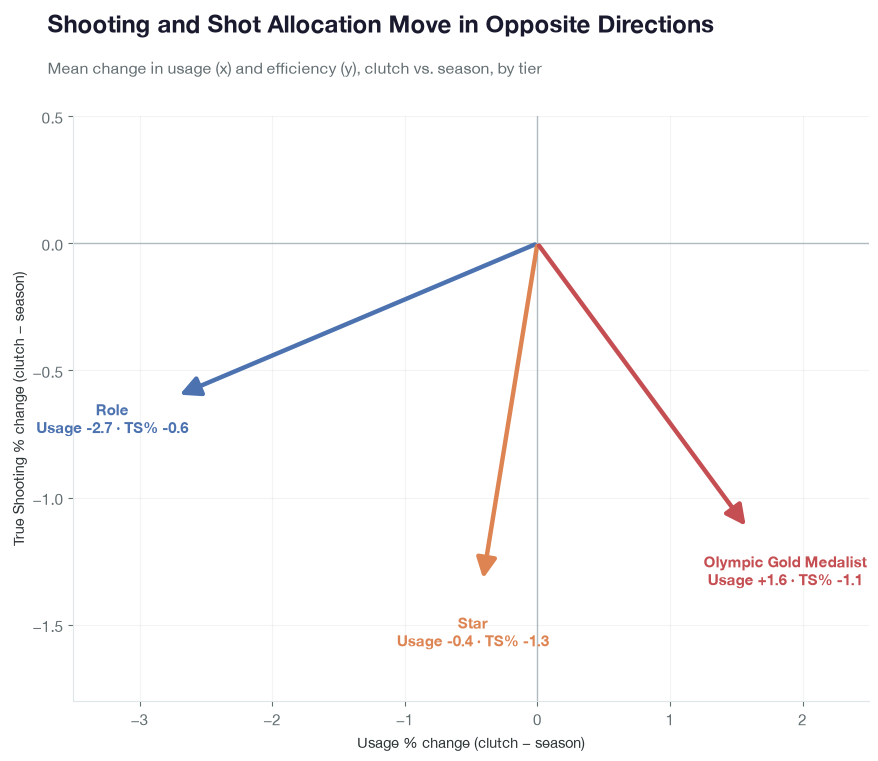

In [82]:
tier_deltas = df.groupby('group')[['TS_DELTA', 'USG_DELTA']].mean().reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.axhline(0, color='#B2BEC3', linewidth=1, zorder=1)
ax.axvline(0, color='#B2BEC3', linewidth=1, zorder=1)

for tier in tier_order:
    dx = tier_deltas.loc[tier, 'USG_DELTA'] * 100
    dy = tier_deltas.loc[tier, 'TS_DELTA'] * 100
    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=tier_colors[tier],
                                 linewidth=3.2, mutation_scale=30), zorder=3)
    ax.annotate(f'{tier}\nUsage {dx:+.1f} · TS% {dy:+.1f}',
                (dx * 1.18, dy * 1.15), ha='center', va='center', fontsize=10.5,
                fontweight='bold', color=tier_colors[tier])

ax.set_xlim(-3.5, 2.5)
ax.set_ylim(-1.8, 0.5)
ax.set_xlabel('Usage % change (clutch − season)', fontsize=10.5)
ax.set_ylabel('True Shooting % change (clutch − season)', fontsize=10.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.15)

add_titles(fig, 'Shooting and Shot Allocation Move in Opposite Directions',
           'Mean change in usage (x) and efficiency (y), clutch vs. season, by tier')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [83]:
top_clutch_volume = (
    df.sort_values('FGA_CLUTCH', ascending=False)
    .groupby('group')
    .head(15)
    [['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH']]
)
print(top_clutch_volume['group'].value_counts())

group
Olympic Gold Medalist    15
Star                     15
Role                     15
Name: count, dtype: int64


In [84]:
def fetch_shots(player_season_list, point_diff, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} shot rows from cache")
        return out_df

    frames = []
    for i, row in enumerate(player_season_list.itertuples(), start=1):
        try:
            params = dict(player_id=row.PLAYER_ID, team_id=0, season_nullable=row.SEASON,
                          season_type_all_star='Regular Season', context_measure_simple='FGA')
            if point_diff is not None:
                params['point_diff_nullable'] = point_diff
            shots = shotchartdetail.ShotChartDetail(**params).get_data_frames()[0]
            shots['PLAYER_ID'] = row.PLAYER_ID
            shots['SEASON'] = row.SEASON
            shots['group'] = row.group
            frames.append(shots)
        except Exception as e:
            print(f"failed for {row.PLAYER_NAME} ({row.SEASON}): {e}")
        print(f"{i}/{len(player_season_list)} pulled ({row.PLAYER_NAME}, {row.SEASON})")
        time.sleep(0.6)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_parquet(cache_path)
    return out_df

season_shots_df = fetch_shots(top_clutch_volume, None, 'shot_selection_season.parquet')
close_game_shots_df = fetch_shots(top_clutch_volume, 5, 'shot_selection_closegame.parquet')

Loaded 65674 shot rows from cache
Loaded 34686 shot rows from cache


In [85]:
true_clutch_shots = close_game_shots_df[
    (close_game_shots_df['PERIOD'] >= 4) &
    (close_game_shots_df['MINUTES_REMAINING'] < 5)
].copy()

print(f"{len(season_shots_df)} season shots, {len(close_game_shots_df)} close-game shots, "
      f"{len(true_clutch_shots)} true clutch shots")
print(true_clutch_shots.groupby('group').size())

65674 season shots, 34686 close-game shots, 5528 true clutch shots
group
Olympic Gold Medalist    2114
Role                     1574
Star                     1840
dtype: int64


## Chart 6

*Sub-question: does shot selection shift under pressure?*  Stars shift toward the rim, Olympic Gold Medalists shift toward threes, Role shifts away from mid-range. The only chart where tiers move in different directions.

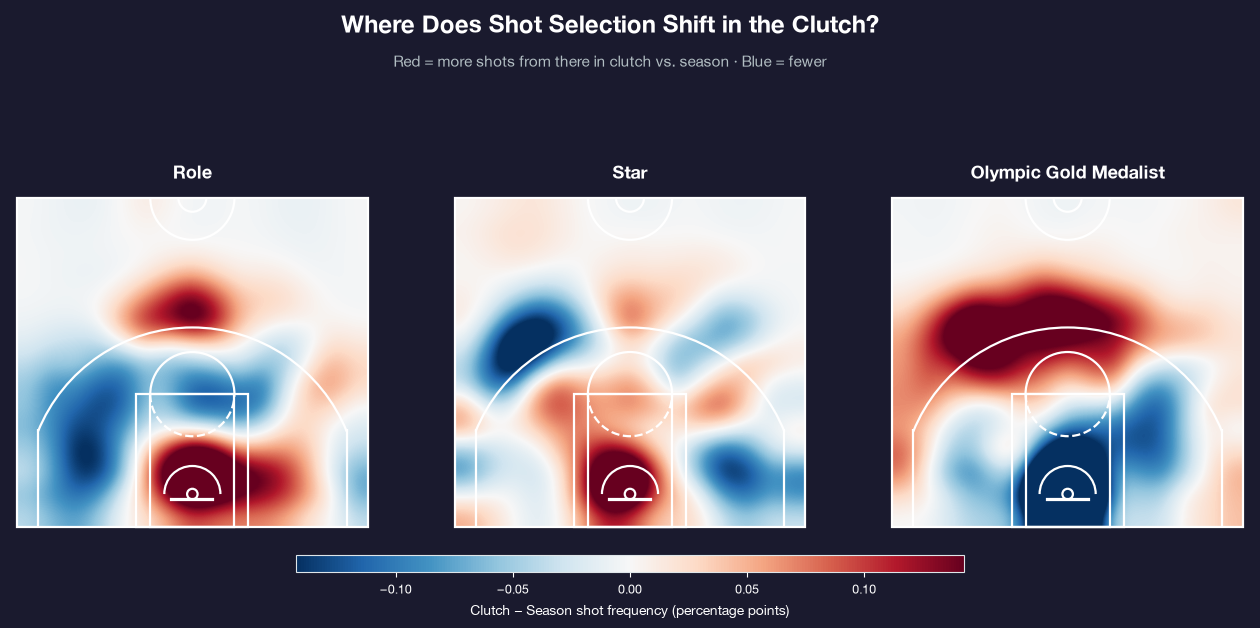

In [86]:
def draw_court(ax, color='white', lw=1.6):
    elements = [
        patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False),
        patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color),
        patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False),
        patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False),
        patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color),
        patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed'),
        patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color),
        patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color),
        patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color),
        patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color),
        patches.Arc((0, 422.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color),
        patches.Arc((0, 422.5), 40, 40, theta1=180, theta2=360, linewidth=lw, color=color),
        patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False),
    ]
    for el in elements:
        ax.add_patch(el)

xedges = np.linspace(-250, 250, 16)
yedges = np.linspace(-47.5, 422.5, 16)

fig, axes = plt.subplots(1, 3, figsize=(16, 6.2))
fig.patch.set_facecolor('#1A1A2E')

diffs = {}
for tier in tier_order:
    s = season_shots_df[season_shots_df['group'] == tier]
    c = true_clutch_shots[true_clutch_shots['group'] == tier]
    s_hist, _, _ = np.histogram2d(s['LOC_X'], s['LOC_Y'], bins=[xedges, yedges])
    c_hist, _, _ = np.histogram2d(c['LOC_X'], c['LOC_Y'], bins=[xedges, yedges])
    diff = (c_hist / c_hist.sum() - s_hist / s_hist.sum()) * 100
    diffs[tier] = gaussian_filter(diff, sigma=0.9)

vmax = np.percentile(np.abs(np.concatenate([d.ravel() for d in diffs.values()])), 92)

for ax, tier in zip(axes, tier_order):
    ax.set_facecolor('#1A1A2E')
    im = ax.imshow(diffs[tier].T, origin='lower', extent=[-250, 250, -47.5, 422.5],
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='bicubic')
    draw_court(ax, color='white')
    ax.set_xlim(-260, 260)
    ax.set_ylim(-60, 430)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(tier, color='white', fontsize=13, fontweight='bold', pad=10)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.035, pad=0.04, aspect=40)
cbar.set_label('Clutch − Season shot frequency (percentage points)', color='white', fontsize=10)
cbar.ax.xaxis.set_tick_params(color='white', labelsize=9)
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='white')

fig.text(0.5, 0.98, 'Where Does Shot Selection Shift in the Clutch?', fontsize=17,
          fontweight='bold', ha='center', color='white')
fig.text(0.5, 0.925, 'Red = more shots from there in clutch vs. season · Blue = fewer',
          fontsize=11, color='#B2BEC3', ha='center')

plt.savefig('shot_selection_court.png', dpi=130, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

In [87]:
sample_sizes = {'Role': 269, 'Star': 70, 'Olympic Gold Medalist': 106}

matchup_sample = pd.concat([
    df[df['group'] == tier].sort_values('FGA_CLUTCH', ascending=False).head(n)
    for tier, n in sample_sizes.items()
])[['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH']]

print(matchup_sample['group'].value_counts())

group
Role                     269
Olympic Gold Medalist    106
Star                      70
Name: count, dtype: int64


In [88]:
def fetch_primary_defenders(player_season_list, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} rows from cache")
        return out_df

    results = []
    for i, row in enumerate(player_season_list.itertuples(), start=1):
        try:
            matchups = leagueseasonmatchups.LeagueSeasonMatchups(
                season=row.SEASON, off_player_id_nullable=row.PLAYER_ID
            ).get_data_frames()[0]
            if not matchups.empty:
                top = matchups.sort_values('MATCHUP_TIME_SEC', ascending=False).iloc[0]
                results.append({
                    'PLAYER_ID': row.PLAYER_ID, 'PLAYER_NAME': row.PLAYER_NAME,
                    'SEASON': row.SEASON, 'group': row.group,
                    'DEF_PLAYER_ID': top['DEF_PLAYER_ID'], 'DEF_PLAYER_NAME': top['DEF_PLAYER_NAME'],
                    'MATCHUP_MIN': top['MATCHUP_MIN']
                })
        except Exception as e:
            print(f"failed for {row.PLAYER_NAME}: {e}")
        print(f"{i}/{len(player_season_list)} pulled")
        time.sleep(0.6)

    out_df = pd.DataFrame(results)
    out_df.to_parquet(cache_path)
    return out_df

primary_defenders_df = fetch_primary_defenders(matchup_sample, 'primary_defenders_v2.parquet')
print(f"{len(primary_defenders_df)} defenders matched")

Loaded 163 rows from cache
163 defenders matched


In [89]:
defender_quality = player_stats_advanced_df[['PLAYER_ID', 'SEASON', 'DEF_RATING']].rename(
    columns={'PLAYER_ID': 'DEF_PLAYER_ID', 'DEF_RATING': 'DEFENDER_DEF_RATING'}
)

matchup_analysis = primary_defenders_df.merge(defender_quality, on=['DEF_PLAYER_ID', 'SEASON'], how='left')
matchup_analysis = matchup_analysis.merge(
    df[['PLAYER_ID', 'SEASON', 'TS_DELTA']], on=['PLAYER_ID', 'SEASON'], how='inner'
)
matchup_analysis = matchup_analysis.dropna(subset=['DEFENDER_DEF_RATING'])

print(f"{len(matchup_analysis)} total rows")
print(matchup_analysis['group'].value_counts())

corr_stats = {}
for tier in tier_order:
    sub = matchup_analysis[matchup_analysis['group'] == tier]
    r, p = scipy_stats.pearsonr(sub['DEFENDER_DEF_RATING'], sub['TS_DELTA'])
    corr_stats[tier] = (r, p)
    print(f"{tier}: r={r:.2f}, p={p:.3f}, n={len(sub)}")

163 total rows
group
Role                     84
Olympic Gold Medalist    44
Star                     35
Name: count, dtype: int64
Role: r=-0.01, p=0.893, n=84
Star: r=-0.18, p=0.294, n=35
Olympic Gold Medalist: r=0.08, p=0.584, n=44


## Chart 7

*Sub-question: is underperformance matchup-driven?* Primary defender quality vs. clutch TS% change, by tier — none of the three correlations are significant. A clean, honest null result.

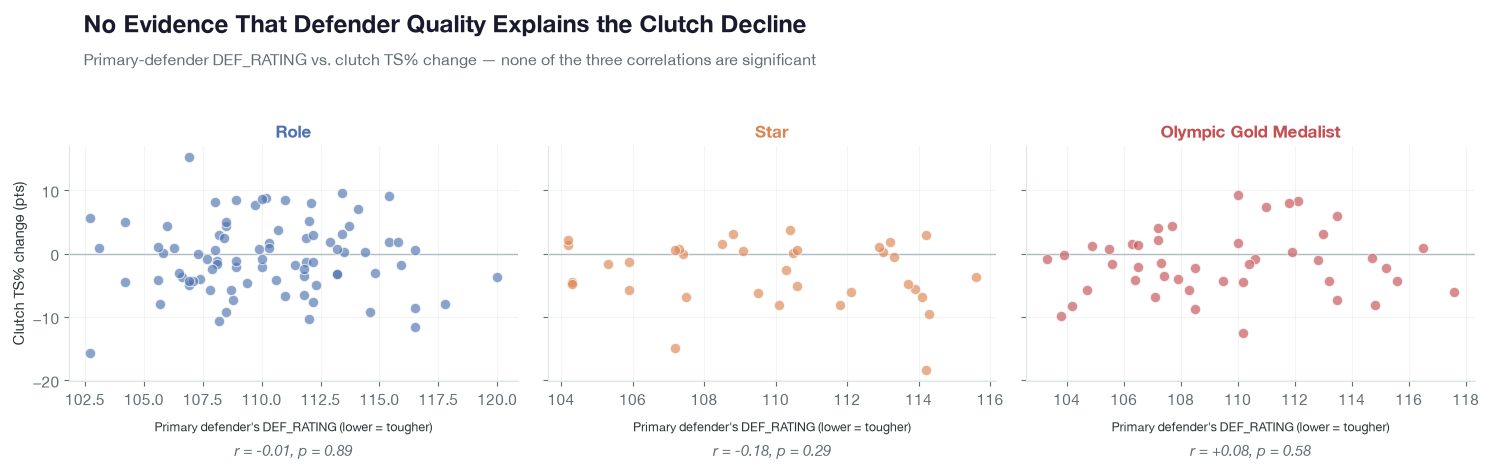

In [90]:
stats_text = {tier: f'r = {corr_stats[tier][0]:+.2f}, p = {corr_stats[tier][1]:.2f}' for tier in tier_order}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, tier in zip(axes, tier_order):
    sub = matchup_analysis[matchup_analysis['group'] == tier]
    ax.scatter(sub['DEFENDER_DEF_RATING'], sub['TS_DELTA'] * 100, s=55,
               color=tier_colors[tier], alpha=0.65, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='#B2BEC3', linewidth=1, zorder=0)

    ax.set_title(tier, fontsize=12.5, fontweight='bold', color=tier_colors[tier])
    ax.set_xlabel("Primary defender's DEF_RATING (lower = tougher)", fontsize=9, labelpad=8)
    ax.text(0.5, -0.32, stats_text[tier], transform=ax.transAxes, ha='center',
            fontsize=10.5, color='#636E72', style='italic')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.15)

axes[0].set_ylabel('Clutch TS% change (pts)', fontsize=10.5)

add_titles(fig, 'No Evidence That Defender Quality Explains the Clutch Decline',
           'Primary-defender DEF_RATING vs. clutch TS% change — none of the three correlations are significant')

plt.tight_layout(rect=[0, 0.12, 1, 0.86])
plt.show()

In [121]:
player_career_clutch = df.groupby(['PLAYER_ID', 'PLAYER_NAME', 'group']).agg(
    n_seasons=('SEASON', 'count'),
    mean_ts_delta=('TS_DELTA', 'mean'),
    median_ts_delta=('TS_DELTA', 'median'),
    std_ts_delta=('TS_DELTA', 'std'),
).reset_index()

print(player_career_clutch['n_seasons'].value_counts().sort_index())
print()
print(f"Players with 3+ qualifying seasons: {(player_career_clutch['n_seasons'] >= 3).sum()}")
print(f"Players with 5+ qualifying seasons: {(player_career_clutch['n_seasons'] >= 5).sum()}")
print(f"Players with 8+ qualifying seasons: {(player_career_clutch['n_seasons'] >= 8).sum()}")

n_seasons
1     245
2     130
3     129
4     102
5      78
6      79
7      66
8      52
9      43
10     36
11     28
12     19
13     17
14     16
15      6
16      4
17      6
18      1
20      1
22      1
Name: count, dtype: int64

Players with 3+ qualifying seasons: 684
Players with 5+ qualifying seasons: 453
Players with 8+ qualifying seasons: 230


In [122]:
for floor in [3, 5, 8]:
    eligible = player_career_clutch[player_career_clutch['n_seasons'] >= floor]
    print(f"--- {floor}+ seasons ---")
    print(eligible['group'].value_counts())
    print()

--- 3+ seasons ---
group
Role                     518
Star                     119
Olympic Gold Medalist     47
Name: count, dtype: int64

--- 5+ seasons ---
group
Role                     308
Star                     100
Olympic Gold Medalist     45
Name: count, dtype: int64

--- 8+ seasons ---
group
Role                     126
Star                      65
Olympic Gold Medalist     39
Name: count, dtype: int64



In [123]:
consistent = player_career_clutch[player_career_clutch['n_seasons'] >= 8].copy()

top_risers = consistent.loc[consistent.groupby('group')['mean_ts_delta'].idxmax()].set_index('group')
top_fallers = consistent.loc[consistent.groupby('group')['mean_ts_delta'].idxmin()].set_index('group')

for tier in tier_order:
    r, f = top_risers.loc[tier], top_fallers.loc[tier]
    print(f"{tier}")
    print(f"  Riser:  {r['PLAYER_NAME']} — mean {r['mean_ts_delta']*100:+.1f} pts, "
          f"median {r['median_ts_delta']*100:+.1f}, std {r['std_ts_delta']*100:.1f}, n={r['n_seasons']} seasons")
    print(f"  Faller: {f['PLAYER_NAME']} — mean {f['mean_ts_delta']*100:+.1f} pts, "
          f"median {f['median_ts_delta']*100:+.1f}, std {f['std_ts_delta']*100:.1f}, n={f['n_seasons']} seasons")
    print()

Role
  Riser:  Amir Johnson — mean +12.0 pts, median +8.1, std 16.0, n=8 seasons
  Faller: Martell Webster — mean -11.3 pts, median -13.0, std 18.6, n=8 seasons

Star
  Riser:  Shawn Marion — mean +6.3 pts, median +3.4, std 10.5, n=10 seasons
  Faller: Jameer Nelson — mean -8.1 pts, median -6.6, std 10.1, n=14 seasons

Olympic Gold Medalist
  Riser:  Jason Kidd — mean +4.8 pts, median +6.9, std 13.6, n=9 seasons
  Faller: Zach LaVine — mean -7.2 pts, median -8.2, std 5.4, n=9 seasons



In [124]:
consistent['t_stat'] = consistent['mean_ts_delta'] / (consistent['std_ts_delta'] / np.sqrt(consistent['n_seasons']))

top_risers_v2 = consistent.loc[consistent.groupby('group')['t_stat'].idxmax()].set_index('group')
top_fallers_v2 = consistent.loc[consistent.groupby('group')['t_stat'].idxmin()].set_index('group')

for tier in tier_order:
    r, f = top_risers_v2.loc[tier], top_fallers_v2.loc[tier]
    print(f"{tier}")
    print(f"  Riser:  {r['PLAYER_NAME']} — mean {r['mean_ts_delta']*100:+.1f}, std {r['std_ts_delta']*100:.1f}, t={r['t_stat']:.2f}, n={r['n_seasons']}")
    print(f"  Faller: {f['PLAYER_NAME']} — mean {f['mean_ts_delta']*100:+.1f}, std {f['std_ts_delta']*100:.1f}, t={f['t_stat']:.2f}, n={f['n_seasons']}")
    print()

Role
  Riser:  Derrick Favors — mean +9.5, std 7.7, t=3.53, n=8
  Faller: Nick Young — mean -11.2, std 13.1, t=-2.71, n=10

Star
  Riser:  Shawn Marion — mean +6.3, std 10.5, t=1.92, n=10
  Faller: Kawhi Leonard — mean -6.9, std 5.9, t=-4.05, n=12

Olympic Gold Medalist
  Riser:  Chris Bosh — mean +3.9, std 9.9, t=1.38, n=12
  Faller: Zach LaVine — mean -7.2, std 5.4, t=-4.02, n=9



In [126]:
case_players = ['Kawhi Leonard', 'Zach LaVine']
case_seasons_df = df[df['PLAYER_NAME'].isin(case_players)][
    ['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH', 'TS_DELTA', 'USG_DELTA']
].copy()

print(case_seasons_df.groupby('PLAYER_NAME').size())
case_seasons_df

PLAYER_NAME
Kawhi Leonard    12
Zach LaVine       9
dtype: int64


,PLAYER_ID,PLAYER_NAME,SEASON,group,FGA_CLUTCH,TS_DELTA,USG_DELTA
2603,202695,Kawhi Leonard,2011-12,Star,10,-0.159,-0.030
2965,202695,Kawhi Leonard,2012-13,Star,29,0.042,-0.014
3326,202695,Kawhi Leonard,2013-14,Star,14,-0.031,-0.051
3702,202695,Kawhi Leonard,2014-15,Star,25,-0.129,-0.023
3884,203897,Zach LaVine,2014-15,Olympic Gold Medalist,18,-0.021,0.022
4080,202695,Kawhi Leonard,2015-16,Star,43,-0.071,0.001
4260,203897,Zach LaVine,2015-16,Olympic Gold Medalist,64,-0.100,-0.009
4454,202695,Kawhi Leonard,2016-17,Star,97,-0.045,0.092
4636,203897,Zach LaVine,2016-17,Olympic Gold Medalist,31,-0.121,-0.052
5233,202695,Kawhi Leonard,2018-19,Star,109,-0.014,0.098


In [127]:
case_season_shots_v2 = fetch_shots(case_seasons_df, None, 'case_study_v2_season_shots.parquet')
case_close_shots_v2 = fetch_shots(case_seasons_df, 5, 'case_study_v2_closegame_shots.parquet')

case_true_clutch_shots_v2 = case_close_shots_v2[
    (case_close_shots_v2['PERIOD'] >= 4) & (case_close_shots_v2['MINUTES_REMAINING'] < 5)
].copy()

print(case_true_clutch_shots_v2.groupby('PLAYER_NAME').size())

1/21 pulled (Kawhi Leonard, 2011-12)
2/21 pulled (Kawhi Leonard, 2012-13)
3/21 pulled (Kawhi Leonard, 2013-14)
4/21 pulled (Kawhi Leonard, 2014-15)
5/21 pulled (Zach LaVine, 2014-15)
6/21 pulled (Kawhi Leonard, 2015-16)
7/21 pulled (Zach LaVine, 2015-16)
8/21 pulled (Kawhi Leonard, 2016-17)
9/21 pulled (Zach LaVine, 2016-17)
10/21 pulled (Kawhi Leonard, 2018-19)
11/21 pulled (Zach LaVine, 2018-19)
12/21 pulled (Kawhi Leonard, 2019-20)
13/21 pulled (Zach LaVine, 2019-20)
14/21 pulled (Kawhi Leonard, 2020-21)
15/21 pulled (Zach LaVine, 2020-21)
16/21 pulled (Zach LaVine, 2021-22)
17/21 pulled (Kawhi Leonard, 2022-23)
18/21 pulled (Zach LaVine, 2022-23)
19/21 pulled (Kawhi Leonard, 2023-24)
20/21 pulled (Zach LaVine, 2024-25)
21/21 pulled (Kawhi Leonard, 2025-26)
1/21 pulled (Kawhi Leonard, 2011-12)
2/21 pulled (Kawhi Leonard, 2012-13)
3/21 pulled (Kawhi Leonard, 2013-14)
4/21 pulled (Kawhi Leonard, 2014-15)
5/21 pulled (Zach LaVine, 2014-15)
6/21 pulled (Kawhi Leonard, 2015-16)
7/21 pull

In [128]:
case_defenders_v2 = fetch_primary_defenders(case_seasons_df, 'case_study_v2_defenders.parquet')
print(case_defenders_v2.groupby('PLAYER_NAME')['DEF_PLAYER_NAME'].value_counts())

1/21 pulled
2/21 pulled
3/21 pulled
4/21 pulled
5/21 pulled
6/21 pulled
7/21 pulled
8/21 pulled
9/21 pulled
10/21 pulled
11/21 pulled
12/21 pulled
13/21 pulled
14/21 pulled
15/21 pulled
16/21 pulled
17/21 pulled
18/21 pulled
19/21 pulled
20/21 pulled
21/21 pulled
PLAYER_NAME    DEF_PLAYER_NAME
Kawhi Leonard  Aaron Gordon       2
               Thabo Sefolosha    1
               P.J. Tucker        1
               De'Andre Hunter    1
               Harrison Barnes    1
               Jaden McDaniels    1
Zach LaVine    Bradley Beal       2
               Eric Bledsoe       1
               Kevin Huerter      1
               Quentin Grimes     1
               Dyson Daniels      1
Name: count, dtype: int64


In [129]:
usg_career = df[df['PLAYER_NAME'].isin(case_players)].groupby('PLAYER_NAME')['USG_DELTA'].mean()

In [130]:
zone_map = {
    'Restricted Area': 'Rim', 'In The Paint (Non-RA)': 'Paint', 'Mid-Range': 'Mid-Range',
    'Left Corner 3': '3-Pointer', 'Right Corner 3': '3-Pointer', 'Above the Break 3': '3-Pointer',
    'Backcourt': 'Other',
}
case_season_shots_v2['zone_simple'] = case_season_shots_v2['SHOT_ZONE_BASIC'].map(zone_map)
case_true_clutch_shots_v2['zone_simple'] = case_true_clutch_shots_v2['SHOT_ZONE_BASIC'].map(zone_map)

case_findings_v2 = []
for name in case_players:
    tier = consistent[consistent['PLAYER_NAME'] == name]['group'].values[0]
    med_ts = consistent[consistent['PLAYER_NAME'] == name]['median_ts_delta'].values[0]
    n_seasons_val = consistent[consistent['PLAYER_NAME'] == name]['n_seasons'].values[0]

    s_mix = case_season_shots_v2[case_season_shots_v2['PLAYER_NAME'] == name]['zone_simple'].value_counts(normalize=True)
    c_shots = case_true_clutch_shots_v2[case_true_clutch_shots_v2['PLAYER_NAME'] == name]
    c_mix = c_shots['zone_simple'].value_counts(normalize=True)
    zone_shift = (c_mix - s_mix).fillna(0) * 100
    top_zone = zone_shift.abs().idxmax()
    top_zone_val = zone_shift[top_zone]

    top_defender = case_defenders_v2[case_defenders_v2['PLAYER_NAME'] == name]['DEF_PLAYER_NAME'].mode()
    top_defender_name = top_defender.values[0] if len(top_defender) else 'N/A'
    defender_count = (case_defenders_v2[case_defenders_v2['PLAYER_NAME'] == name]['DEF_PLAYER_NAME'] == top_defender_name).sum()

    case_findings_v2.append({
        'PLAYER_NAME': name, 'group': tier, 'n_seasons': n_seasons_val,
        'median_ts_delta': med_ts, 'usg_delta': usg_career[name],
        'zone_shift_label': f"{top_zone_val:+.1f} pts at {top_zone.lower()}",
        'top_defender': f"{top_defender_name} ({defender_count}/{n_seasons_val} seasons)",
        'n_clutch_shots': len(c_shots)
    })

case_findings_v2_df = pd.DataFrame(case_findings_v2)
case_findings_v2_df

,PLAYER_NAME,group,n_seasons,median_ts_delta,usg_delta,zone_shift_label,top_defender,n_clutch_shots
0,Kawhi Leonard,Star,12,-0.0585,0.021167,+4.0 pts at mid-range,Aaron Gordon (2/12 seasons),567
1,Zach LaVine,Olympic Gold Medalist,9,-0.0820,0.041556,-4.1 pts at rim,Bradley Beal (2/9 seasons),577


In [131]:
unique_defenders = case_defenders_v2.groupby('PLAYER_NAME')['DEF_PLAYER_NAME'].nunique()
print(unique_defenders)

PLAYER_NAME
Kawhi Leonard    6
Zach LaVine      5
Name: DEF_PLAYER_NAME, dtype: int64


In [91]:
hr_cols = ['PLAYER_ID', 'SEASON', 'GP', 'TS_PCT', 'NET_RATING', 'USG_PCT']

hr = (home_clutch_df[hr_cols]
      .merge(road_clutch_df[hr_cols], on=['PLAYER_ID', 'SEASON'], suffixes=('_HOME', '_ROAD')))
hr = hr[(hr['GP_HOME'] >= 8) & (hr['GP_ROAD'] >= 8)].copy()
hr = hr.merge(df[['PLAYER_ID', 'SEASON', 'PLAYER_NAME', 'group']], on=['PLAYER_ID', 'SEASON'], how='inner')

hr['TS_GAP'] = (hr['TS_PCT_HOME'] - hr['TS_PCT_ROAD']) * 100
hr['NET_GAP'] = hr['NET_RATING_HOME'] - hr['NET_RATING_ROAD']

tier_gaps = hr.groupby('group')[['TS_GAP', 'NET_GAP']].mean().reindex(tier_order)
hr_counts = hr['group'].value_counts().reindex(tier_order)
print(f"{len(hr)} player-seasons with 8+ clutch games home and road")
tier_gaps

4382 player-seasons with 8+ clutch games home and road


,TS_GAP,NET_GAP
group,,
Role,1.598874,8.383072
Star,1.532321,8.841540
Olympic Gold Medalist,2.612830,7.903208


In [138]:
case_players = ['Derrick Favors', 'Kawhi Leonard', 'Zach LaVine']
case_seasons_df = df[df['PLAYER_NAME'].isin(case_players)][
    ['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH', 'TS_DELTA', 'USG_DELTA']
].copy()
print(case_seasons_df.groupby('PLAYER_NAME').size())

PLAYER_NAME
Derrick Favors     8
Kawhi Leonard     12
Zach LaVine        9
dtype: int64


In [139]:
case_season_shots_v2 = fetch_shots(case_seasons_df, None, 'case_study_v3_season_shots.parquet')
case_close_shots_v2 = fetch_shots(case_seasons_df, 5, 'case_study_v3_closegame_shots.parquet')
case_true_clutch_shots_v2 = case_close_shots_v2[
    (case_close_shots_v2['PERIOD'] >= 4) & (case_close_shots_v2['MINUTES_REMAINING'] < 5)
].copy()

case_defenders_v2 = fetch_primary_defenders(case_seasons_df, 'case_study_v3_defenders.parquet')

1/29 pulled (Derrick Favors, 2010-11)
2/29 pulled (Derrick Favors, 2011-12)
3/29 pulled (Kawhi Leonard, 2011-12)
4/29 pulled (Derrick Favors, 2012-13)
5/29 pulled (Kawhi Leonard, 2012-13)
6/29 pulled (Derrick Favors, 2013-14)
7/29 pulled (Kawhi Leonard, 2013-14)
8/29 pulled (Derrick Favors, 2014-15)
9/29 pulled (Kawhi Leonard, 2014-15)
10/29 pulled (Zach LaVine, 2014-15)
11/29 pulled (Derrick Favors, 2015-16)
12/29 pulled (Kawhi Leonard, 2015-16)
13/29 pulled (Zach LaVine, 2015-16)
14/29 pulled (Kawhi Leonard, 2016-17)
15/29 pulled (Zach LaVine, 2016-17)
16/29 pulled (Derrick Favors, 2017-18)
17/29 pulled (Kawhi Leonard, 2018-19)
18/29 pulled (Zach LaVine, 2018-19)
19/29 pulled (Derrick Favors, 2019-20)
20/29 pulled (Kawhi Leonard, 2019-20)
21/29 pulled (Zach LaVine, 2019-20)
22/29 pulled (Kawhi Leonard, 2020-21)
23/29 pulled (Zach LaVine, 2020-21)
24/29 pulled (Zach LaVine, 2021-22)
25/29 pulled (Kawhi Leonard, 2022-23)
26/29 pulled (Zach LaVine, 2022-23)
27/29 pulled (Kawhi Leonard, 

In [142]:
zone_map = {
    'Restricted Area': 'Rim', 'In The Paint (Non-RA)': 'Paint', 'Mid-Range': 'Mid-Range',
    'Left Corner 3': '3-Pointer', 'Right Corner 3': '3-Pointer', 'Above the Break 3': '3-Pointer',
    'Backcourt': 'Other',
}
case_season_shots_v2['zone_simple'] = case_season_shots_v2['SHOT_ZONE_BASIC'].map(zone_map)
case_true_clutch_shots_v2['zone_simple'] = case_true_clutch_shots_v2['SHOT_ZONE_BASIC'].map(zone_map)

print(case_true_clutch_shots_v2[case_true_clutch_shots_v2['PLAYER_NAME']=='Derrick Favors']['zone_simple'].value_counts())

zone_simple
Rim          97
Mid-Range    28
Paint        26
3-Pointer     3
Name: count, dtype: int64


In [149]:
usg_career_v3 = df[df['PLAYER_NAME'].isin(case_players)].groupby('PLAYER_NAME')['USG_DELTA'].mean()
unique_defenders_v3 = case_defenders_v2.groupby('PLAYER_NAME')['DEF_PLAYER_NAME'].nunique()

case_findings_v3 = []
for name in case_players:
    tier = case_seasons_df[case_seasons_df['PLAYER_NAME'] == name]['group'].iloc[0]
    med_ts = consistent[consistent['PLAYER_NAME'] == name]['median_ts_delta'].values[0]
    n_seasons_val = case_seasons_df[case_seasons_df['PLAYER_NAME'] == name]['SEASON'].nunique()

    s_mix = case_season_shots_v2[case_season_shots_v2['PLAYER_NAME'] == name]['zone_simple'].value_counts(normalize=True)
    c_shots = case_true_clutch_shots_v2[case_true_clutch_shots_v2['PLAYER_NAME'] == name]
    c_mix = c_shots['zone_simple'].value_counts(normalize=True)
    zone_shift = (c_mix - s_mix).fillna(0) * 100
    top_zone = zone_shift.abs().idxmax()
    top_zone_val = zone_shift[top_zone]

    n_def = unique_defenders_v3.get(name, 0)

    case_findings_v3.append({
        'PLAYER_NAME': name, 'group': tier, 'n_seasons': n_seasons_val,
        'median_ts_delta': med_ts, 'usg_delta': usg_career_v3[name],
        'zone_shift_label': f"{top_zone_val:+.1f} pts at {top_zone.lower()}",
        'n_defenders': n_def, 'n_clutch_shots': len(c_shots)
    })

case_findings_v3_df = pd.DataFrame(case_findings_v3)
case_findings_v3_df

,PLAYER_NAME,group,n_seasons,median_ts_delta,usg_delta,zone_shift_label,n_defenders,n_clutch_shots
0,Derrick Favors,Role,8,0.0880,-0.053125,+9.0 pts at rim,2,154
1,Kawhi Leonard,Star,12,-0.0585,0.021167,+4.0 pts at mid-range,6,567
2,Zach LaVine,Olympic Gold Medalist,9,-0.0820,0.041556,-4.1 pts at rim,5,577


In [154]:
game_clutch = case_true_clutch_shots_v2.groupby(['PLAYER_NAME', 'GAME_ID', 'GAME_DATE']).agg(
    fga=('SHOT_MADE_FLAG', 'count'),
    fgm=('SHOT_MADE_FLAG', 'sum'),
).reset_index()
game_clutch['fg_pct'] = game_clutch['fgm'] / game_clutch['fga']

print(game_clutch.groupby('PLAYER_NAME')['fga'].describe())

                count      mean       std  min  25%  50%  75%   max
PLAYER_NAME                                                        
Derrick Favors   83.0  1.855422  1.240894  1.0  1.0  1.0  2.0   6.0
Kawhi Leonard   205.0  2.765854  1.863952  1.0  1.0  2.0  3.0  12.0
Zach LaVine     197.0  2.928934  2.115305  1.0  1.0  2.0  4.0  18.0


In [155]:
floor = 3  # adjust based on what the describe() output shows
game_clutch_filtered = game_clutch[game_clutch['fga'] >= floor]

for name in case_players:
    sub = game_clutch_filtered[game_clutch_filtered['PLAYER_NAME'] == name]
    if len(sub) == 0:
        print(f"{name}: no games meet the {floor}+ shot floor")
        continue
    best = sub.loc[sub['fg_pct'].idxmax()]
    worst = sub.loc[sub['fg_pct'].idxmin()]
    print(f"{name} (n={len(sub)} qualifying games)")
    print(f"  Best:  {best['GAME_DATE']}  {best['fgm']:.0f}/{best['fga']:.0f} ({best['fg_pct']*100:.0f}%)")
    print(f"  Worst: {worst['GAME_DATE']}  {worst['fgm']:.0f}/{worst['fga']:.0f} ({worst['fg_pct']*100:.0f}%)")
    print()

Derrick Favors (n=19 qualifying games)
  Best:  20151118  3/3 (100%)
  Worst: 20120125  1/4 (25%)

Kawhi Leonard (n=99 qualifying games)
  Best:  20221217  3/3 (100%)
  Worst: 20141203  0/3 (0%)

Zach LaVine (n=94 qualifying games)
  Best:  20221221  3/3 (100%)
  Worst: 20150325  0/5 (0%)



In [156]:
for name in case_players:
    sub = game_clutch_filtered[game_clutch_filtered['PLAYER_NAME'] == name]
    n_ties_best = (sub['fg_pct'] == sub['fg_pct'].max()).sum()
    print(f"{name}: {n_ties_best} different games tied at the best percentage ({sub['fg_pct'].max()*100:.0f}%)")

Derrick Favors: 2 different games tied at the best percentage (100%)
Kawhi Leonard: 4 different games tied at the best percentage (100%)
Zach LaVine: 1 different games tied at the best percentage (100%)


In [157]:
season_fg_pct = case_season_shots_v2.groupby('PLAYER_NAME')['SHOT_MADE_FLAG'].mean()

game_clutch['expected_fgm'] = game_clutch.apply(
    lambda row: row['fga'] * season_fg_pct[row['PLAYER_NAME']], axis=1
)
game_clutch['makes_above_expected'] = game_clutch['fgm'] - game_clutch['expected_fgm']

floor = 3
game_clutch_filtered = game_clutch[game_clutch['fga'] >= floor]

for name in case_players:
    sub = game_clutch_filtered[game_clutch_filtered['PLAYER_NAME'] == name]
    best = sub.loc[sub['makes_above_expected'].idxmax()]
    worst = sub.loc[sub['makes_above_expected'].idxmin()]
    print(f"{name} (n={len(sub)} qualifying games)")
    print(f"  Best:  {best['GAME_DATE']}  {best['fgm']:.0f}/{best['fga']:.0f} ({best['fg_pct']*100:.0f}%), "
          f"+{best['makes_above_expected']:.1f} makes above expected")
    print(f"  Worst: {worst['GAME_DATE']}  {worst['fgm']:.0f}/{worst['fga']:.0f} ({worst['fg_pct']*100:.0f}%), "
          f"{worst['makes_above_expected']:.1f} makes above expected")
    print()

Derrick Favors (n=19 qualifying games)
  Best:  20200116  4/4 (100%), +1.9 makes above expected
  Worst: 20120125  1/4 (25%), -1.1 makes above expected

Kawhi Leonard (n=99 qualifying games)
  Best:  20130322  4/5 (80%), +1.5 makes above expected
  Worst: 20170303  1/8 (12%), -3.0 makes above expected

Zach LaVine (n=94 qualifying games)
  Best:  20230317  7/9 (78%), +2.7 makes above expected
  Worst: 20150325  0/5 (0%), -2.4 makes above expected



In [161]:
def format_date(d):
    return datetime.datetime.strptime(str(int(d)), '%Y%m%d').strftime('%B %d, %Y')

print(format_date(20200116))  # -> January 16, 2020

January 16, 2020


## Chart 8

Every player with 8+ qualifying clutch seasons, plotted by career median TS% change against how consistent that pattern is (lower = more consistent). Derrick Favors, Kawhi Leonard, and Zach LaVine are the three most statistically reliable patterns in the entire dataset. Note the near-empty bottom-right: consistent improvement is rare; consistent decline is not.

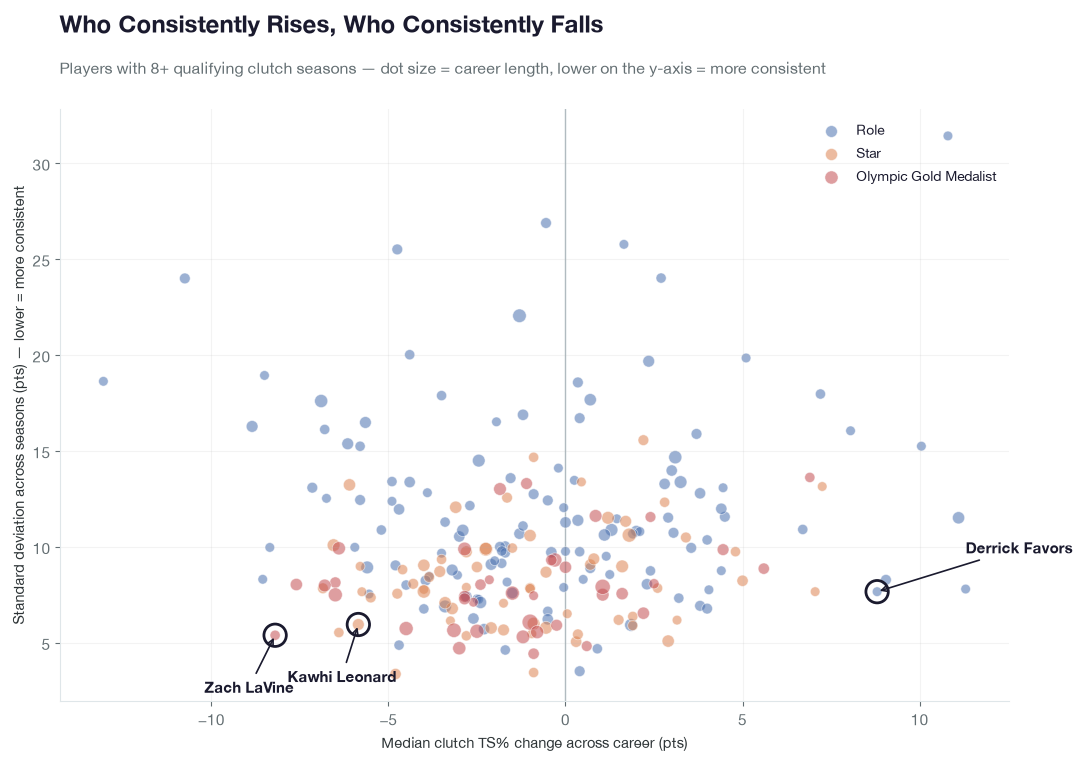

In [153]:
fig, ax = plt.subplots(figsize=(11, 7.5))

for tier in tier_order:
    sub = consistent[consistent['group'] == tier]
    ax.scatter(sub['median_ts_delta']*100, sub['std_ts_delta']*100,
               s=sub['n_seasons']*6, color=tier_colors[tier], alpha=0.55,
               edgecolor='white', linewidth=0.6, label=tier)

ax.axvline(0, color='#B2BEC3', linewidth=1, zorder=0)

callouts = [('Derrick Favors', 2.5, 2), ('Kawhi Leonard', -2, -3), ('Zach LaVine', -2, -3)]
for name, dx, dy in callouts:
    row = consistent[consistent['PLAYER_NAME'] == name].iloc[0]
    x, y = row['median_ts_delta']*100, row['std_ts_delta']*100
    ax.scatter([x], [y], s=260, facecolor='none', edgecolor='#1A1A2E', linewidth=2, zorder=5)
    ax.annotate(name, (x, y), xytext=(x+dx, y+dy), fontsize=10.5, fontweight='bold', color='#1A1A2E',
                arrowprops=dict(arrowstyle='->', color='#1A1A2E', linewidth=1.2))

ax.set_xlabel('Median clutch TS% change across career (pts)', fontsize=10.5)
ax.set_ylabel('Standard deviation across seasons (pts) — lower = more consistent', fontsize=10.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.15)
ax.legend(loc='upper right', frameon=False, fontsize=10)

add_titles(fig, 'Who Consistently Rises, Who Consistently Falls',
           'Players with 8+ qualifying clutch seasons — dot size = career length, lower on the y-axis = more consistent')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## Chart 9

FG% change by zone, clutch vs. season, for all three case studies. Favors' one reliable zone (rim, real sample) shows him shooting *better* under pressure — a genuine riser story built on simplified shot selection. Kawhi and Zach both decline in every zone with real volume behind each bar, but for different reasons: Kawhi's shot selection barely changes, Zach's gets harder — shown in the context line under each panel.

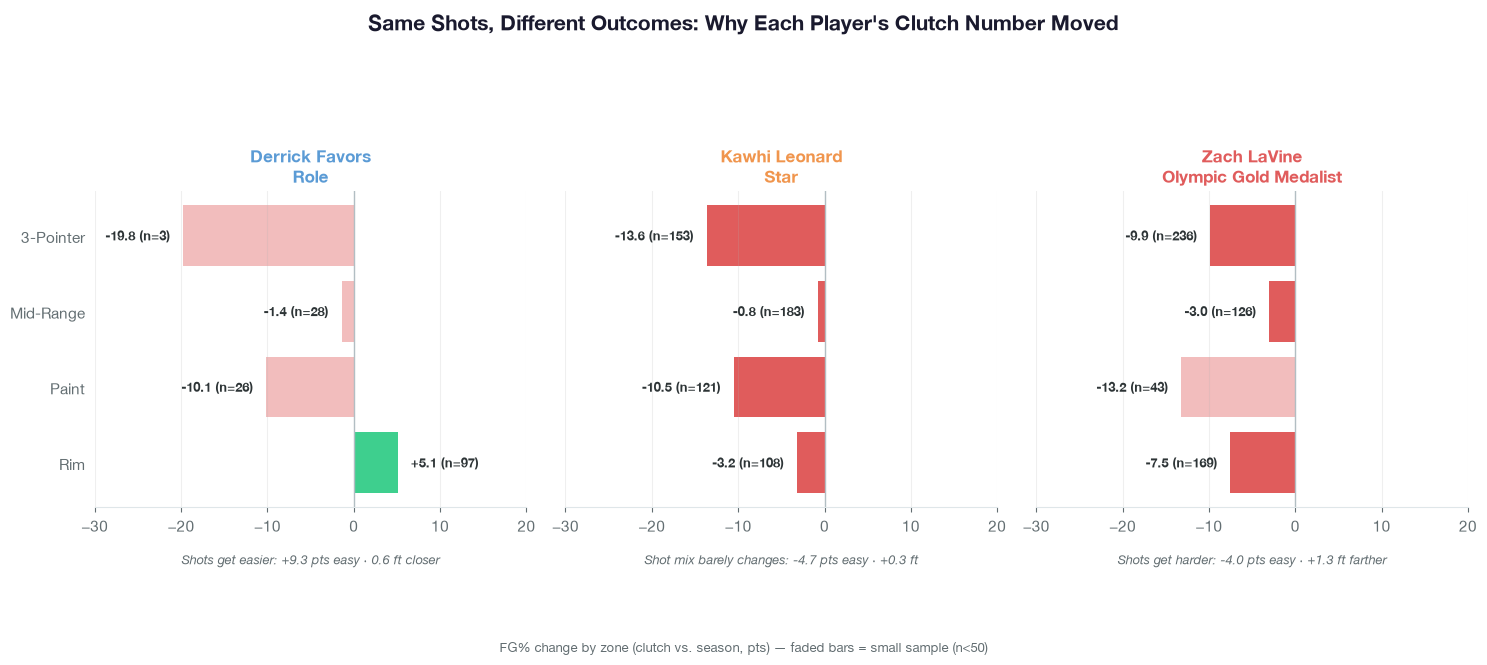

In [144]:
zone_order = ['Rim', 'Paint', 'Mid-Range', '3-Pointer']
context_labels = {
    'Derrick Favors': 'Shots get easier: +9.3 pts easy · 0.6 ft closer',
    'Kawhi Leonard': 'Shot mix barely changes: -4.7 pts easy · +0.3 ft',
    'Zach LaVine': 'Shots get harder: -4.0 pts easy · +1.3 ft farther',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, name in zip(axes, case_players):
    tier = case_seasons_df[case_seasons_df['PLAYER_NAME']==name]['group'].iloc[0]
    s = case_season_shots_v2[case_season_shots_v2['PLAYER_NAME']==name]
    c = case_true_clutch_shots_v2[case_true_clutch_shots_v2['PLAYER_NAME']==name]
    s_fg = s.groupby('zone_simple')['SHOT_MADE_FLAG'].mean()
    c_fg = c.groupby('zone_simple')['SHOT_MADE_FLAG'].mean()
    c_n = c.groupby('zone_simple').size()

    vals = [(c_fg.get(z, np.nan) - s_fg.get(z, np.nan))*100 for z in zone_order]
    ns = [c_n.get(z, 0) for z in zone_order]
    colors = ['#3ECF8E' if v >= 0 else '#E05C5C' for v in vals]

    y = range(len(zone_order))
    bars = ax.barh(y, vals, color=colors)
    for bar, n in zip(bars, ns):
        bar.set_alpha(1.0 if n >= 50 else 0.4)

    for yi, v, n in zip(y, vals, ns):
        label_x = v + (1.5 if v >= 0 else -1.5)
        ax.text(label_x, yi, f"{v:+.1f} (n={n})", va='center',
                ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold', color='#2D3436')

    ax.set_yticks(y)
    ax.set_yticklabels(zone_order, fontsize=11)
    ax.axvline(0, color='#B2BEC3', linewidth=1)
    ax.set_xlim(-30, 20)
    ax.set_title(f"{name}\n{tier}", fontsize=12, fontweight='bold', color=scoreboard_colors[tier])
    ax.text(0.5, -0.18, context_labels[name], transform=ax.transAxes, ha='center',
            fontsize=9, color='#636E72', style='italic')
    ax.spines[['top','right','left']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(left=False)

fig.text(0.5, -0.02, 'FG% change by zone (clutch vs. season, pts) — faded bars = small sample (n<50)',
          ha='center', fontsize=9.5, color='#636E72')
fig.suptitle("Same Shots, Different Outcomes: Why Each Player's Clutch Number Moved",
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0,0.05,1,0.92])
plt.show()

## Chart 9b

Full-career clutch shot locations — hundreds of real shots per player instead of one season's ~21. Favors' shots cluster tightly near the rim; Kawhi and Zach's spread wider toward the arc. Visually confirms the zone-accuracy findings from Chart 9.

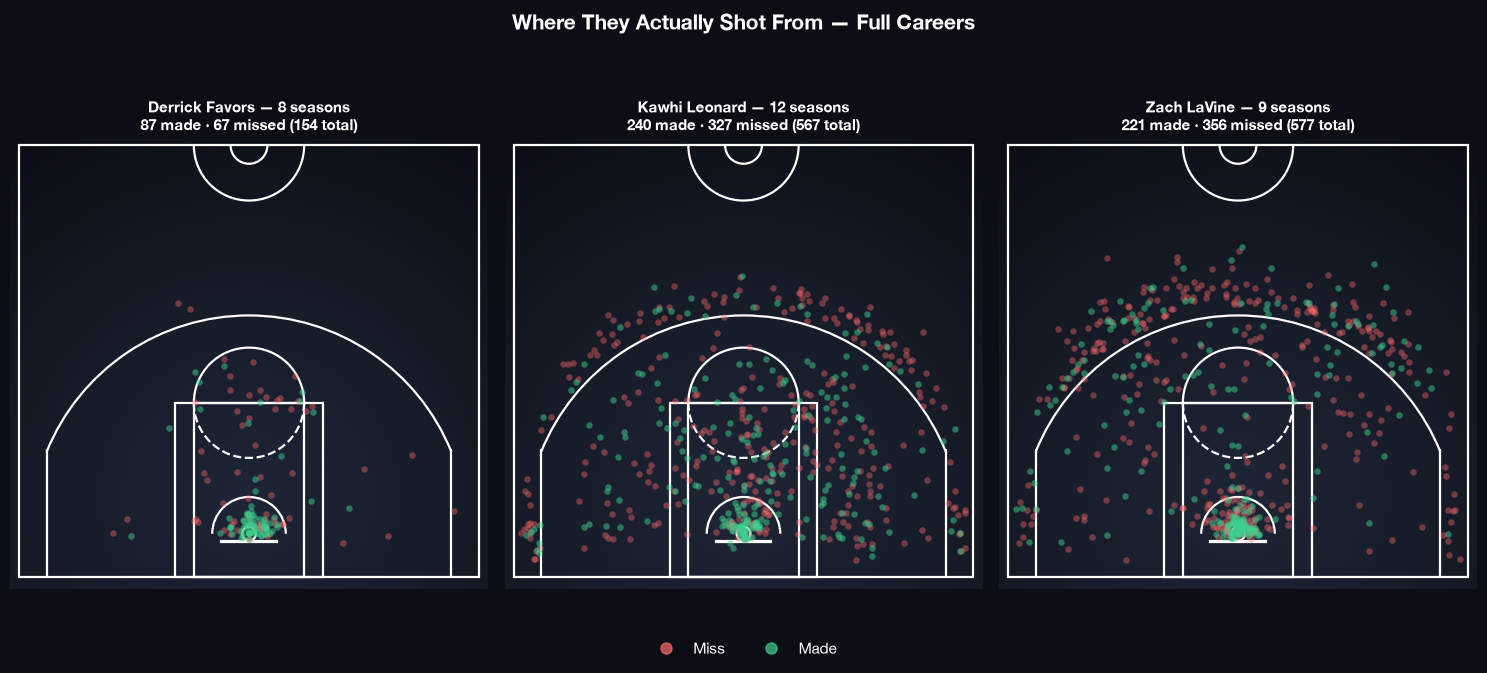

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6.3))
fig.patch.set_facecolor('#0B0E14')

xx, yy = np.meshgrid(np.linspace(-260, 260, 300), np.linspace(-60, 430, 300))
dist = np.sqrt(xx**2 + (yy - 40)**2)
grad = np.clip(1 - (dist / dist.max()), 0, 1)
glow_cmap = LinearSegmentedColormap.from_list('glow', ['#0B0E14', '#161B27', '#1E2536'])

for ax, name in zip(axes, case_players):
    player_shots = case_true_clutch_shots_v2[case_true_clutch_shots_v2['PLAYER_NAME'] == name]
    made = player_shots[player_shots['SHOT_MADE_FLAG'] == 1]
    missed = player_shots[player_shots['SHOT_MADE_FLAG'] == 0]
    n_seasons_val = case_seasons_df[case_seasons_df['PLAYER_NAME'] == name]['SEASON'].nunique()

    ax.set_facecolor('#0B0E14')
    ax.imshow(grad, extent=[-260, 260, -60, 430], origin='lower', cmap=glow_cmap, aspect='auto', zorder=0)
    draw_court(ax, color='white')
    ax.scatter(missed['LOC_X'], missed['LOC_Y'], s=22, color='#FF6B6B', alpha=0.4, linewidth=0, zorder=2)
    ax.scatter(made['LOC_X'], made['LOC_Y'], s=22, color='#3ECF8E', alpha=0.5, linewidth=0, zorder=3)

    ax.set_xlim(-260, 260)
    ax.set_ylim(-60, 430)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"{name} — {n_seasons_val} seasons\n{len(made)} made · {len(missed)} missed ({len(player_shots)} total)",
                 fontsize=10.5, fontweight='bold', color='white')

legend_elements = [plt.Line2D([0],[0], marker='o', color='#FF6B6B', linestyle='', label='Miss', markersize=8, alpha=0.7),
                   plt.Line2D([0],[0], marker='o', color='#3ECF8E', linestyle='', label='Made', markersize=8, alpha=0.7)]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02),
           labelcolor='white')

fig.suptitle('Where They Actually Shot From — Full Careers', fontsize=15, fontweight='bold', y=1.03, color='white')
plt.tight_layout()
plt.show()

## Chart 9c

Each player's single best and single worst clutch game, ranked by makes above what their season shooting would predict (not raw percentage, which ties too easily on tiny samples). An anecdote on top of the career-level finding, not new evidence on its own — real games, but only 3-9 shots each.

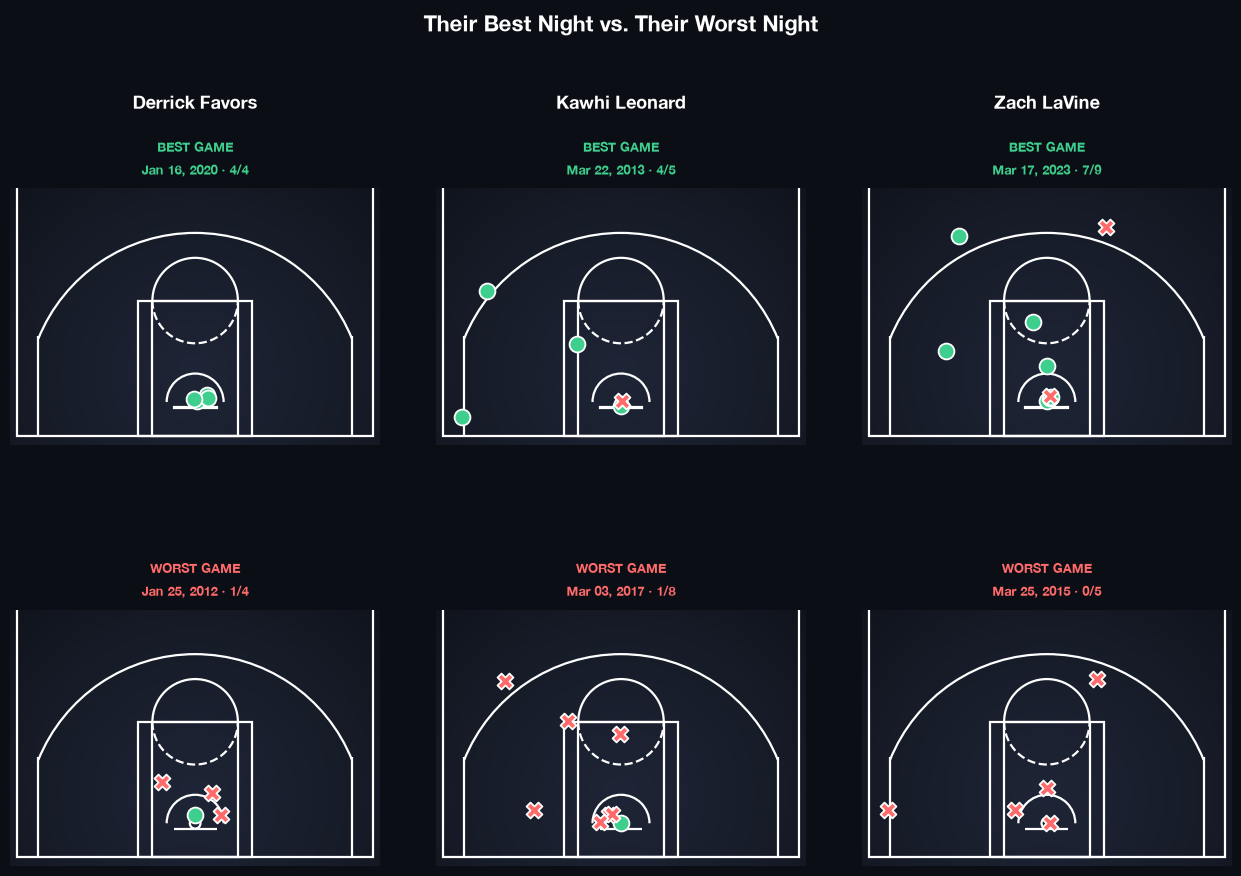

In [170]:
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
fig.patch.set_facecolor('#0B0E14')
fig.subplots_adjust(hspace=0.55, wspace=0.15, top=0.80, bottom=0.03, left=0.03, right=0.97)

xx, yy = np.meshgrid(np.linspace(-260, 260, 300), np.linspace(-60, 430, 300))
dist = np.sqrt(xx**2 + (yy - 40)**2)
grad = np.clip(1 - (dist / dist.max()), 0, 1)
glow_cmap = LinearSegmentedColormap.from_list('glow', ['#0B0E14', '#161B27', '#1E2536'])

for col, name in enumerate(case_players):
    best_game = best_worst_games[name]['best']
    worst_game = best_worst_games[name]['worst']

    for row, (game, label, color) in enumerate([(best_game, 'BEST GAME', '#3ECF8E'), (worst_game, 'WORST GAME', '#FF6B6B')]):
        ax = axes[row, col]
        game_shots = case_true_clutch_shots_v2[
            (case_true_clutch_shots_v2['PLAYER_NAME'] == name) &
            (case_true_clutch_shots_v2['GAME_ID'] == game['GAME_ID'])
        ]

        ax.set_facecolor('#0B0E14')
        ax.imshow(grad, extent=[-260, 260, -60, 430], origin='lower', cmap=glow_cmap, aspect='auto', zorder=0)
        draw_court(ax, color='white')

        made = game_shots[game_shots['SHOT_MADE_FLAG'] == 1]
        missed = game_shots[game_shots['SHOT_MADE_FLAG'] == 0]
        ax.scatter(made['LOC_X'], made['LOC_Y'], s=130, color='#3ECF8E', edgecolor='white', linewidth=1.3, zorder=3, marker='o')
        ax.scatter(missed['LOC_X'], missed['LOC_Y'], s=130, color='#FF6B6B', edgecolor='white', linewidth=1.3, zorder=3, marker='X')

        ax.set_xlim(-260, 260)
        ax.set_ylim(-60, 300)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(f"{label}\n{format_date(game['GAME_DATE'])} · {game['fgm']:.0f}/{game['fga']:.0f}",
                     fontsize=9, fontweight='bold', color=color, pad=10, linespacing=1.6)

for col, name in enumerate(case_players):
    x_pos = axes[0, col].get_position().x0 + axes[0, col].get_position().width/2
    fig.text(x_pos, 0.88, name, fontsize=13, fontweight='bold', color='white', ha='center')

fig.suptitle('Their Best Night vs. Their Worst Night', fontsize=16, fontweight='bold', y=0.99, color='white')
plt.show()

## Chart 9d

Career summary for the three case studies: median clutch TS% change, usage change, biggest shot-zone shift, and matchup pattern, aggregated across each player's full qualifying career. A recap of the headline numbers behind everything just shown in Charts 9 through 9c.

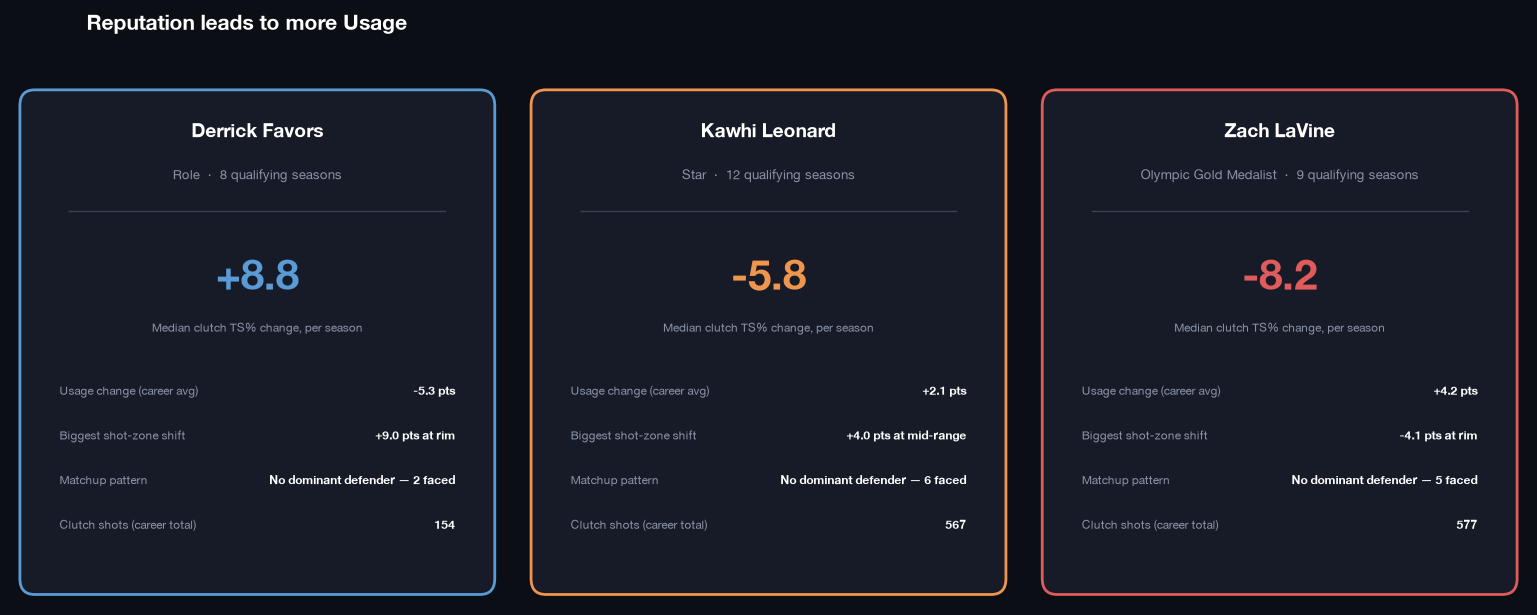

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 6))
fig.patch.set_facecolor('#0B0E14')

for ax, (_, c) in zip(axes, case_findings_v3_df.iterrows()):
    ax.set_facecolor('#0B0E14')
    ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    color = scoreboard_colors[c['group']]

    ax.add_patch(patches.FancyBboxPatch((0.03, 0.03), 0.94, 0.94, boxstyle="round,pad=0.01,rounding_size=0.03",
                                          facecolor='#161B27', edgecolor=color, linewidth=2))
    ax.text(0.5, 0.89, c['PLAYER_NAME'], fontsize=14, fontweight='bold', ha='center', color='white')
    ax.text(0.5, 0.81, f"{c['group']}  ·  {c['n_seasons']} qualifying seasons", fontsize=9.5, ha='center', color='#8A93A6')
    ax.plot([0.12, 0.88], [0.75, 0.75], color='#3A4152', linewidth=1)

    ax.text(0.5, 0.60, f"{c['median_ts_delta']*100:+.1f}", fontsize=30, fontweight='bold', ha='center', color=color)
    ax.text(0.5, 0.52, 'Median clutch TS% change, per season', fontsize=8.5, ha='center', color='#8A93A6')

    rows = [
        ('Usage change (career avg)', f"{c['usg_delta']*100:+.1f} pts"),
        ('Biggest shot-zone shift', c['zone_shift_label']),
        ('Matchup pattern', f"No dominant defender — {c['n_defenders']} faced"),
        ('Clutch shots (career total)', str(c['n_clutch_shots'])),
    ]
    y = 0.40
    for label, val in rows:
        ax.text(0.1, y, label, fontsize=8.5, color='#8A93A6', ha='left')
        ax.text(0.9, y, val, fontsize=8.5, fontweight='bold', color='white', ha='right')
        y -= 0.085

fig.suptitle('Reputation leads to more Usage', fontsize=15, fontweight='bold', x=0.06, ha='left', y=1.02, color='white')
plt.tight_layout()
plt.show()

## Chart 10

*Sub-question: do home/road splits matter?* Yes, but similarly across all tiers (TS% and Net Rating both agree). Rules out venue as the reason stars decline more than role players.

/var/folders/vp/pg9__5w51d35qj0z3gpg0dlm0000gn/T/ipykernel_60263/2231015094.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)
/var/folders/vp/pg9__5w51d35qj0z3gpg0dlm0000gn/T/ipykernel_60263/2231015094.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)


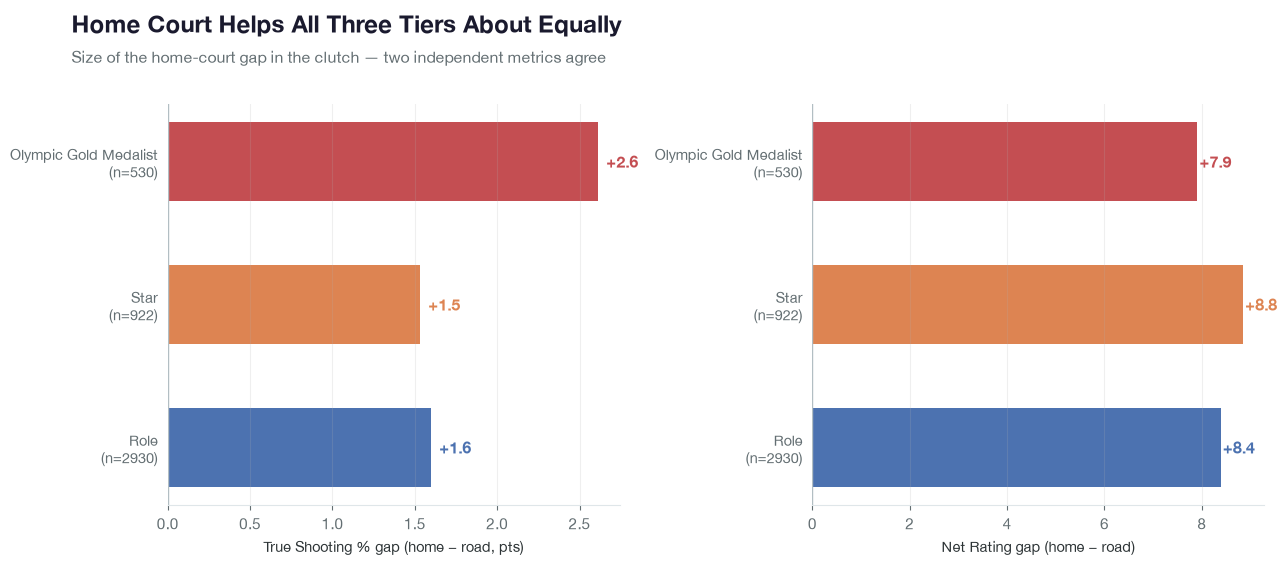

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [('TS_GAP', 'True Shooting % gap (home − road, pts)', axes[0]),
          ('NET_GAP', 'Net Rating gap (home − road)', axes[1])]

for col, xlabel, ax in panels:
    bars = ax.barh(tier_order, tier_gaps[col], color=[tier_colors[t] for t in tier_order], height=0.55)
    for bar, tier in zip(bars, tier_order):
        val = tier_gaps.loc[tier, col]
        ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=11.5, fontweight='bold', color=tier_colors[tier])

    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(left=False)
    ax.axvline(0, color='#B2BEC3', linewidth=1)

add_titles(fig, 'Home Court Helps All Three Tiers About Equally',
           'Size of the home-court gap in the clutch — two independent metrics agree')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

## Chart 11

22-year trend by tier. Olympic Gold Medalist shows a real downward trend (p=0.042); Role shows a step-change after 2011-12 (p=0.008) but no steady trend; Star shows neither. Not uniform across eras — treat as suggestive, not conclusive (multiple tests, no correction).

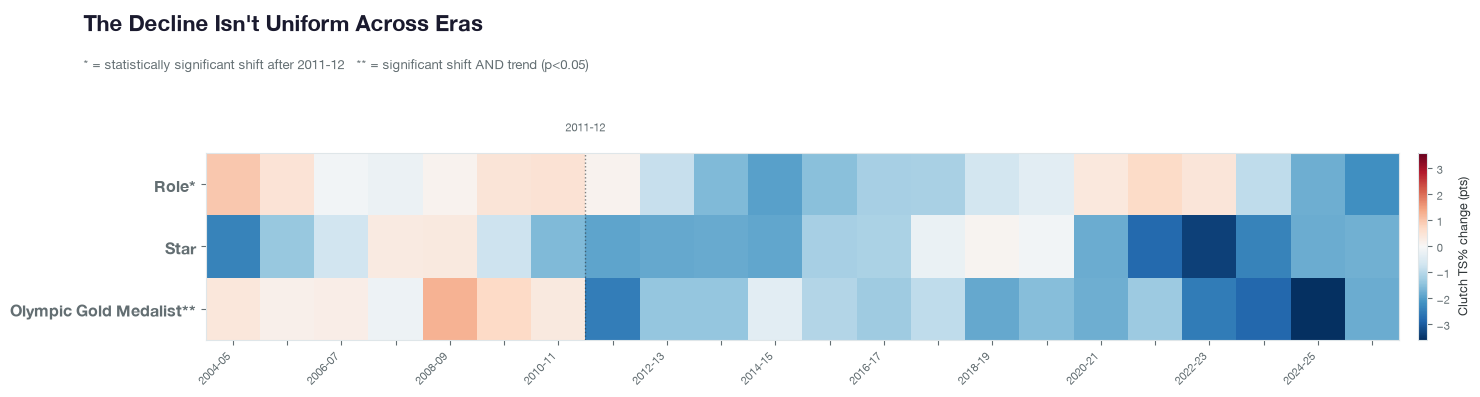

In [99]:
fig, ax = plt.subplots(figsize=(15, 3.8))
vmax = np.abs(smoothed.values).max()
im = ax.imshow(smoothed.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

sig_marks = {'Role': '*', 'Star': '', 'Olympic Gold Medalist': '**'}
ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels([f'{t}{sig_marks[t]}' for t in tier_order], fontsize=11.5, fontweight='bold')

ax.set_xticks(range(len(season_order)))
xlabels = [s if i % 2 == 0 else '' for i, s in enumerate(season_order)]
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)

split_idx = season_order.index('2011-12')
ax.axvline(split_idx - 0.5, color='#2D3436', linewidth=1, linestyle=':', alpha=0.6)
ax.text(split_idx - 0.5, -0.85, '2011-12', ha='center', fontsize=8, color='#636E72')

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.015)
cbar.set_label('Clutch TS% change (pts)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.text(0.06, 0.98, "The Decline Isn't Uniform Across Eras", fontsize=16, fontweight='bold', ha='left')
fig.text(0.06, 0.88, '* = statistically significant shift after 2011-12   ** = significant shift AND trend (p<0.05)',
          fontsize=9.5, color='#636E72', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

## Chart 12

Closing scoreboard restating Chart 5's numbers. Thesis: stars are genuinely better, but in the clutch, who gets the ball tracks reputation more than who's actually shooting well right now.

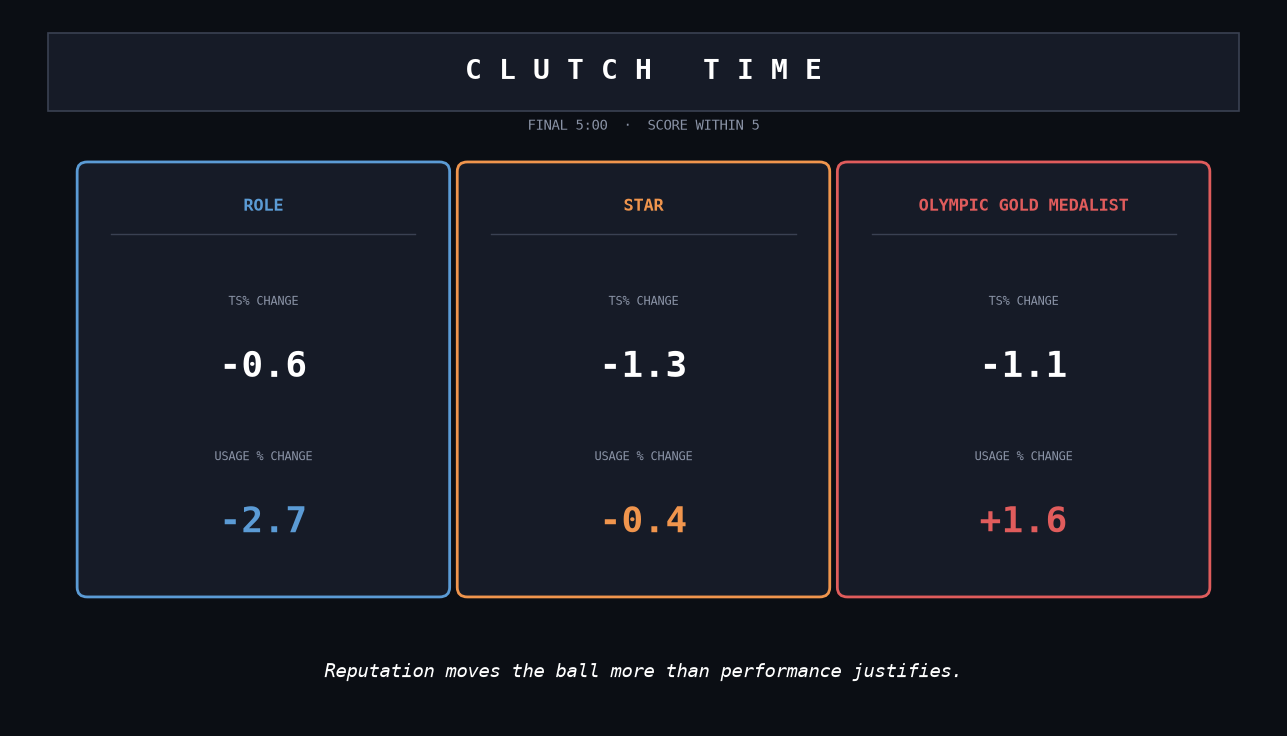

In [95]:
scoreboard_colors = {'Role': '#5B9BD5', 'Star': '#F0954D', 'Olympic Gold Medalist': '#E05C5C'}

fig, ax = plt.subplots(figsize=(13, 7.5))
fig.patch.set_facecolor('#0B0E14')
ax.set_facecolor('#0B0E14')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

header = patches.Rectangle((0.3, 5.15), 9.4, 0.65, facecolor='#161B27', edgecolor='#3A4152', linewidth=1.2)
ax.add_patch(header)
ax.text(5, 5.475, 'C L U T C H   T I M E', fontsize=20, fontweight='bold', color='white',
        ha='center', va='center', fontfamily='monospace')
ax.text(5, 5.02, 'FINAL 5:00  ·  SCORE WITHIN 5', fontsize=10, color='#8A93A6',
        ha='center', va='center', fontfamily='monospace')

panel_w = 2.9
gaps = [0.55, 3.55, 6.55]
for gx, tier in zip(gaps, tier_order):
    ts_val = tier_deltas.loc[tier, 'TS_DELTA'] * 100
    usg_val = tier_deltas.loc[tier, 'USG_DELTA'] * 100

    panel = patches.FancyBboxPatch((gx, 1.1), panel_w, 3.6, boxstyle="round,pad=0.02,rounding_size=0.08",
                                     facecolor='#161B27', edgecolor=scoreboard_colors[tier], linewidth=2)
    ax.add_patch(panel)

    ax.text(gx + panel_w/2, 4.35, tier.upper(), fontsize=12.5, fontweight='bold',
            color=scoreboard_colors[tier], ha='center', va='center', fontfamily='monospace')
    ax.plot([gx+0.25, gx+panel_w-0.25], [4.12, 4.12], color='#3A4152', linewidth=1)

    ax.text(gx + panel_w/2, 3.55, 'TS% CHANGE', fontsize=8.5, color='#8A93A6',
            ha='center', va='center', fontfamily='monospace')
    ax.text(gx + panel_w/2, 3.0, f"{ts_val:+.1f}", fontsize=26, fontweight='bold',
            color='white', ha='center', va='center', fontfamily='monospace')

    ax.text(gx + panel_w/2, 2.25, 'USAGE % CHANGE', fontsize=8.5, color='#8A93A6',
            ha='center', va='center', fontfamily='monospace')
    ax.text(gx + panel_w/2, 1.7, f"{usg_val:+.1f}", fontsize=26, fontweight='bold',
            color=scoreboard_colors[tier], ha='center', va='center', fontfamily='monospace')

ax.text(5, 0.45, 'Reputation moves the ball more than performance justifies.',
        fontsize=13.5, color='white', ha='center', va='center', style='italic', fontfamily='monospace')

plt.tight_layout()
plt.savefig('closing_scoreboard.png', dpi=130, bbox_inches='tight', facecolor='#0B0E14')
plt.show()